In [3]:
"""
Script to visualize pseudobulk splicing PSI data from the long format file
"""

# Load packages we need
import pandas as pd
import os
import sys
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from typing import List, Set, Dict, Any, Optional
from scipy import stats
from sklearn.decomposition import PCA
import gffutils
import random
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.cm as cm

# Alternatively, you can directly specify the path
module_path = "/gpfs/commons/home/kisaev/LeafletFA-utils"

# Add path if not already in sys.path
if module_path not in sys.path:
    sys.path.append(module_path)
    print(f"Added {module_path} to sys.path")

# Now you should be able to import from leafletfa_utils
from leafletfa_utils.atsemapper.main import run_atsemapper # type: ignore
from leafletfa_utils.atseviz.main import * # type: ignore
print("Imports successful!")

# ----- Configuration -----

# Set random seed for reproducibility
np.random.seed(42)
random.seed(42)

# Output directory
output_dir = "/gpfs/commons/groups/knowles_lab/Karin/Leaflet-analysis-WD/HUMAN_SPLICING_FOUNDATION/visualizations"
os.makedirs(output_dir, exist_ok=True)
print(f"Output directory: {output_dir}")

# Timestamp for file naming
timestamp = pd.Timestamp.now().strftime('%Y%m%d_%H%M%S')

Imports successful!
Output directory: /gpfs/commons/groups/knowles_lab/Karin/Leaflet-analysis-WD/HUMAN_SPLICING_FOUNDATION/visualizations


In [2]:
# ----- Load data -----
pseudobulk_file = "/gpfs/commons/groups/knowles_lab/Karin/Leaflet-analysis-WD/HUMAN_SPLICING_FOUNDATION/MODEL_INPUT/102025/pseudobulk_final_broad_cell_type_20251009_010633.csv.gz"
print(f"Loading pseudobulk data from: {pseudobulk_file}")
long_df = pd.read_csv(pseudobulk_file, low_memory=False)
print(f"Loaded {len(long_df)} rows of data with {long_df['cell_type'].nunique()} cell types")

# Load ATSE data
ATSE_file = "/gpfs/commons/groups/knowles_lab/Karin/Leaflet-analysis-WD/HUMAN_SPLICING_FOUNDATION/ATSE_mapper/ATSE_files/HUMAN_FOUNDATION_ATSE_FILE_unanno_also_2025-09-21_05-02-35.txt.gz"
atses = pd.read_csv(ATSE_file, sep="\t")
print(f"Loaded {len(atses)} rows of ATSE data with {len(atses['event_id'].unique())} unique events")

db_file = "/gpfs/commons/groups/knowles_lab/Megan/encode_pacbio/paper_figures/isoform_gazers/long_read_hg38.db"
db = gffutils.FeatureDB(db_file, keep_order=True)
genome_db_available = True

Loading pseudobulk data from: /gpfs/commons/groups/knowles_lab/Karin/Leaflet-analysis-WD/HUMAN_SPLICING_FOUNDATION/MODEL_INPUT/102025/pseudobulk_final_broad_cell_type_20251009_010633.csv.gz
Loaded 5305469 rows of data with 43 cell types
Loaded 160252 rows of ATSE data with 41489 unique events


#### Input: Gene ID or symbol and output: Clustermap output with all gene-junctions-ATSEs displayed PSI by major cell type group

In [4]:
# filter rows where n_cells==0
long_df = long_df[long_df["n_cells"] > 0]

# filter rows where gene_symbol is NaN
long_df = long_df[long_df["gene_symbol"].notna()]

In [5]:
long_df["gene_id"] = long_df["gene_id"].str.split(".").str[0]

In [6]:
long_df["cell_type"].unique()

array(['Regulatory_T_cell', 'Organ_Specific_Fibroblast', 'Smooth_Muscle',
       'Urogenital_Epithelial', 'NK_ILC', 'Pericyte', 'Skeletal_Muscle',
       'GI_Epithelial', 'Dendritic_cell', 'CD4_T_cell', 'Muscle_Other',
       'Secretory_Gland', 'Inhibitory_Neuron', 'Lymphatic_Endothelial',
       'Capillary_Endothelial', 'CD8_T_cell', 'Other_T_cell',
       'Arterial_Endothelial', 'Macrophage', 'Myeloid_Other',
       'Alveolar_cell', 'Stem_Progenitor_Other', 'B_cell',
       'Mesenchymal_Stem', 'Hematopoietic_Progenitor', 'Monocyte',
       'CNS_Glia', 'Plasma_cell', 'Vascular', 'General_Fibroblast',
       'Specialized_Endothelial', 'Respiratory_Epithelial',
       'Venous_Endothelial', 'Immune_Other', 'Microglia',
       'Other_Epithelial', 'Granulocyte', 'Hematopoietic_Mature',
       'Other_Neuron', 'PNS_Glia', 'Excitatory_Neuron'], dtype=object)

In [8]:
# --- 1) Known AS targets as a dictionary ---
AS_MARKERS = {
    "Neurons": {
        "NRXN1": "multiple cassette exons (incl. SS#4/6)",
        "NRXN2": "multiple cassette exons (incl. SS#4/6)",
        "NRXN3": "multiple cassette exons (incl. SS#4/6)",
        "DLG4":  "N-terminal exon cassettes (PSD95)",
        "GRIN1": "exon 5 (N1) cassette",
        "CAMK2B":"microexon inclusion (e.g., exon 13)",
        "SNAP25":"a/b isoforms (dev/neuron-subtype bias)",
        "MAPT":  "exons 2/3 and 10 (Tau)",
        "CACNA1C":"exon 8 vs 8* (8a)",
        "NRG1":  "multiple isoforms"
    },
    "CNS_Glia": {
        "PLP1": "DM20 (exon 3B) ratio shifts (oligodendrocyte)",
        "MBP":  "multiple exons (incl. Golli-MBP) (oligo maturation)",
        "GFAP": "α vs δ isoforms (astrocyte region/subtype)"
    },
    "Immune": {
        "PTPRC": "exons 4–6 (CD45 RA/RB/RO); naive/memory bias",
        "CTLA4": "exon 3 alt splicing → soluble vs membrane",
        "FAS":   "exon 6 skipping → soluble FAS",
        "IL7R":  "exon 6 skipping → soluble IL7R",
        "IGH":   "membrane vs secreted tails (alt last exon)",
        "IGK":   "membrane vs secreted tails (alt last exon)"
    },
    "Epithelial": {
        "FGFR2": "IIIb (epithelial) vs IIIc (mesenchymal)",
        "CFTR":  "exon 9/12 usage variability",
        "CD44":  "variable cassette v2–v10 (EMT/epithelial bias)",
        "EPCAM": "3′ UTR/alt last exon variants"
    },
    "Endothelial_Vascular": {
        "VEGFA": "proximal vs distal 3′SS (e.g., 165 vs 165b)",
        "FLT1":  "alt splicing → sFLT1 (soluble)",
        "MCAM":  "long/short cytoplasmic tails",
        "PECAM1":"exon 14 skipping reported"
    },
    "Muscle": {
        "TTN":   "cardiac (N2B/N2BA) vs skeletal isoforms",
        "TNNT2": "cardiac troponin T exon swaps",
        "TNNI1":"skeletal troponin I exon swaps",
        "TNNI2":"skeletal troponin I exon swaps",
        "TNNI3":"cardiac troponin I exon swaps",
        "TPM1":  "tropomyosin exon swaps",
        "TPM2":  "tropomyosin exon swaps",
        "BIN1":  "exon 11 muscle-specific (T-tubule)",
        "MYH7B":"fiber-type biased splicing"
    },
    "Microglia_Myeloid": {
        "TREM2":"exon 3 skipping → soluble TREM2",
        "CSF1R":"alternative exons affecting signaling"
    }
}

# convenience set of all gene symbols
AS_MARKER_GENES = {g for grp in AS_MARKERS.values() for g in grp.keys()}

In [37]:
long_df[long_df["gene_symbol"] == "NRXN2"]["gene_id"]

1440801    ENSG00000110076
1440802    ENSG00000110076
1440803    ENSG00000110076
1440804    ENSG00000110076
1440805    ENSG00000110076
                ...       
1441140    ENSG00000110076
1441141    ENSG00000110076
1441142    ENSG00000110076
1441143    ENSG00000110076
1441144    ENSG00000110076
Name: gene_id, Length: 328, dtype: object

                       cell_type                junction_id  \
1440801             Immune_Other  chr11_64635452_64642538_-   
1440802             Immune_Other  chr11_64635452_64648218_-   
1440803    Urogenital_Epithelial  chr11_64635452_64642538_-   
1440804                 Monocyte  chr11_64635452_64648218_-   
1440805  Specialized_Endothelial  chr11_64635452_64648218_-   
...                          ...                        ...   
1441140   Respiratory_Epithelial  chr11_64608082_64608563_-   
1441141                 Monocyte  chr11_64608082_64620293_-   
1441142   Respiratory_Epithelial  chr11_64607500_64620293_-   
1441143          Skeletal_Muscle  chr11_64608082_64620293_-   
1441144         Mesenchymal_Stem  chr11_64607500_64620293_-   

         junction_id_index  junction_count  atse_count gene_symbol  psi  \
1440801               9387             0.0         0.0       NRXN2  NaN   
1440802               9388             0.0         0.0       NRXN2  NaN   
1440803           

/scratch/ipykernel_2308534/3391548829.py:31: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = cm.get_cmap('viridis').copy()


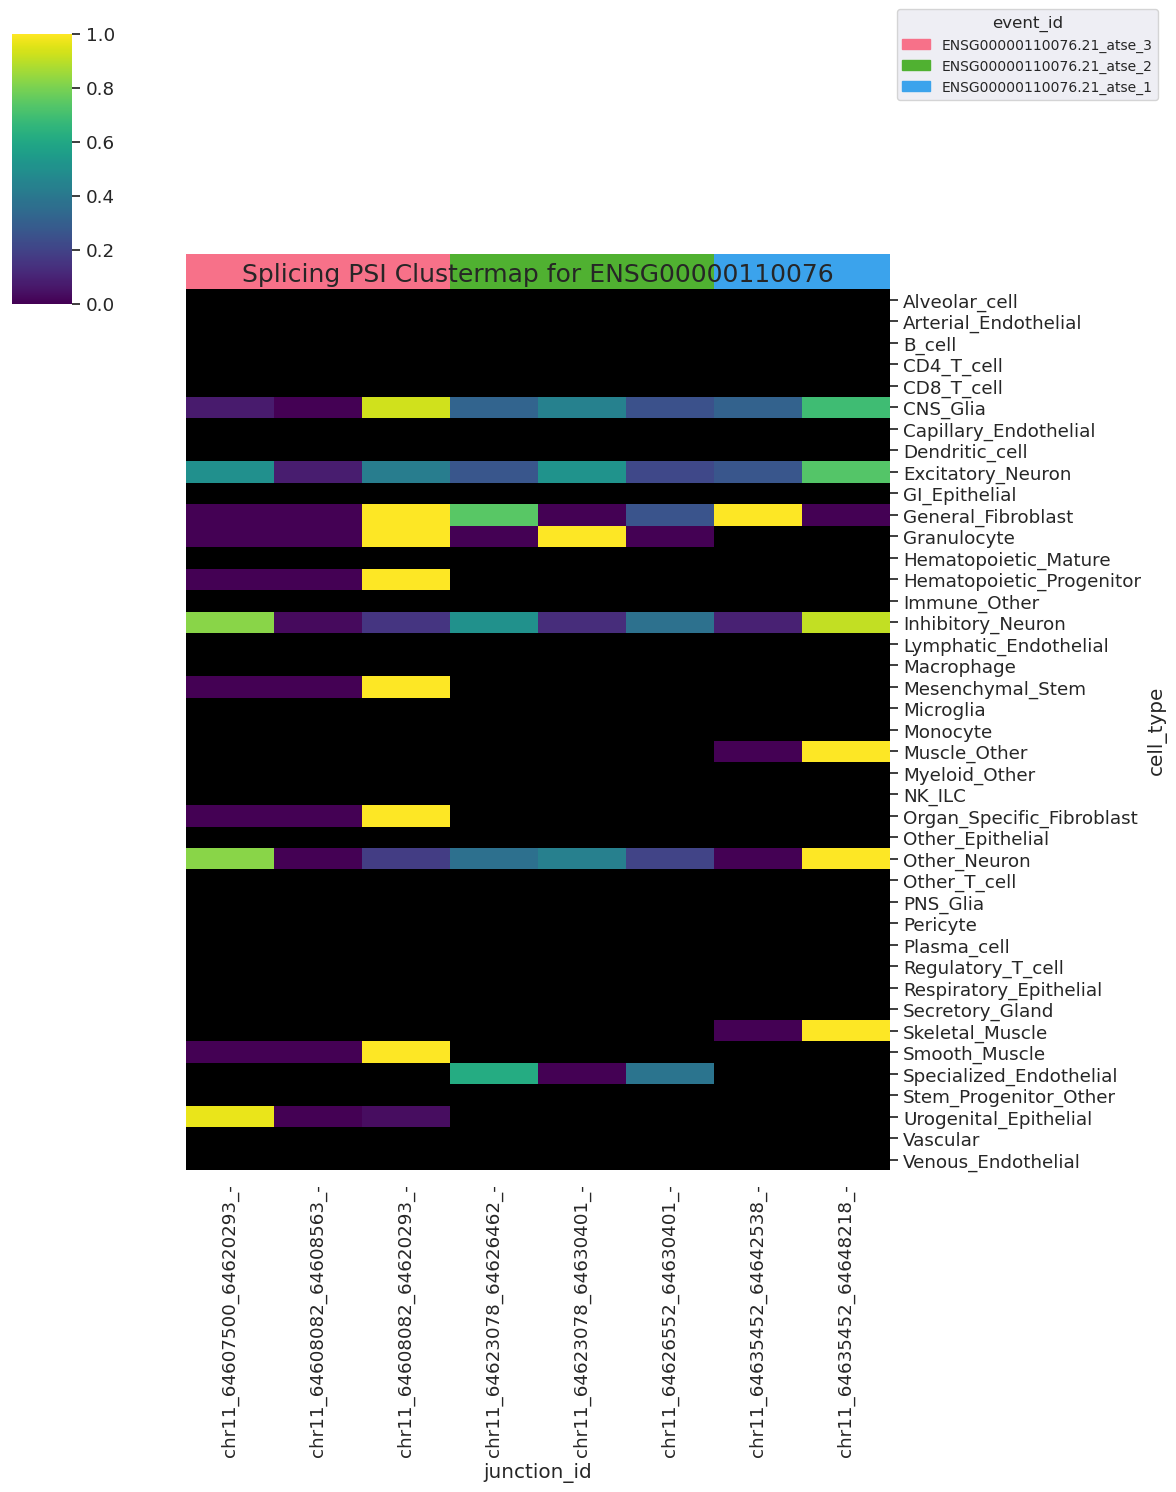

In [38]:
# Sample gene name from your dataset
# gene_name = np.random.choice(long_df["gene_symbol"].unique(), 1)[0]
gene_id = "ENSG00000110076"
gene_vals = long_df[long_df["gene_id"] == gene_id]
print(gene_vals)

# Pivot to create a matrix: rows = cell types, columns = junctions, values = PSI
psi_matrix = gene_vals.pivot(index='cell_type', columns='junction_id', values='psi')

# --- Leave NaNs as they are, do not fill with 0 ---
# psi_matrix = psi_matrix.fillna(0)

# Map junctions to event_ids
junction_to_event = gene_vals.drop_duplicates(subset='junction_id')[['junction_id', 'event_id']]
junction_to_event = junction_to_event.set_index('junction_id')['event_id']

# Create a color palette for event IDs
unique_events = junction_to_event.loc[psi_matrix.columns].unique()
event_palette = sns.color_palette("husl", len(unique_events))
event_lut = dict(zip(unique_events, event_palette))

# Color annotation per junction
col_colors = psi_matrix.columns.map(junction_to_event).map(event_lut)

# Set global font scale
sns.set(font_scale=1.2)

# --- Get the colormap and set the color for NaN values ---
# By default, seaborn uses the 'viridis' colormap. We'll make a copy and modify it.
# You can replace 'viridis' with any other colormap you prefer.
cmap = cm.get_cmap('viridis').copy()
cmap.set_bad('black')

# Generate the clustermap
g = sns.clustermap(
    psi_matrix,
    row_cluster=False,
    col_cluster=False,
    cmap=cmap,  # Use the modified colormap
    col_colors=col_colors,
    figsize=(12, 15),
    xticklabels=True,
    yticklabels=True
)

# Add title with gene name
g.ax_heatmap.set_title(f"Splicing PSI Clustermap for {gene_id}", fontsize=18)

# Add legend for event_ids to the right of the heatmap
from matplotlib.patches import Patch
handles = [Patch(color=event_lut[eid], label=eid) for eid in unique_events]
g.ax_col_dendrogram.legend(
    handles=handles,
    title='event_id',
    bbox_to_anchor=(1.0, 1.1),
    loc='upper left',
    fontsize=10,
    title_fontsize=12
)

plt.show()

                       cell_type                junction_id  \
1440801             Immune_Other  chr11_64635452_64642538_-   
1440802             Immune_Other  chr11_64635452_64648218_-   
1440803    Urogenital_Epithelial  chr11_64635452_64642538_-   
1440804                 Monocyte  chr11_64635452_64648218_-   
1440805  Specialized_Endothelial  chr11_64635452_64648218_-   
...                          ...                        ...   
1441140   Respiratory_Epithelial  chr11_64608082_64608563_-   
1441141                 Monocyte  chr11_64608082_64620293_-   
1441142   Respiratory_Epithelial  chr11_64607500_64620293_-   
1441143          Skeletal_Muscle  chr11_64608082_64620293_-   
1441144         Mesenchymal_Stem  chr11_64607500_64620293_-   

         junction_id_index  junction_count  atse_count gene_symbol  psi  \
1440801               9387             0.0         0.0       NRXN2  NaN   
1440802               9388             0.0         0.0       NRXN2  NaN   
1440803           

/scratch/ipykernel_2308534/1567874773.py:26: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = cm.get_cmap('viridis').copy()


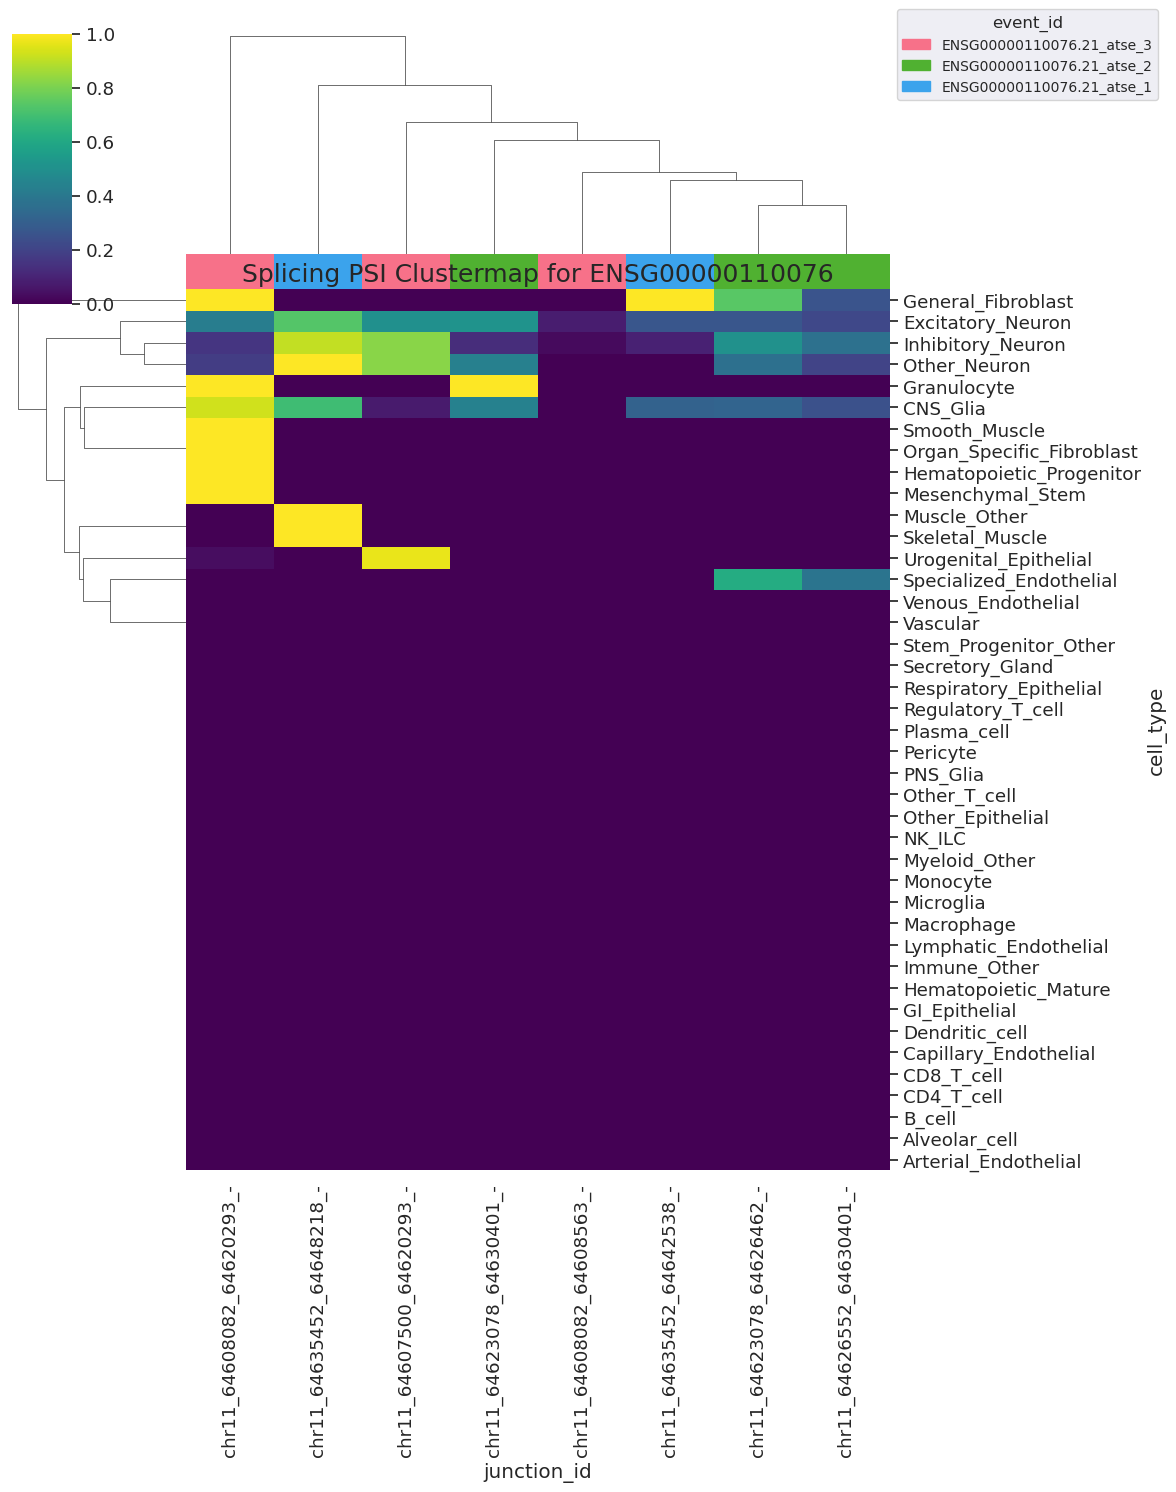

In [39]:
gene_vals = long_df[long_df["gene_id"] == gene_id]
print(gene_vals)

# Pivot to create a matrix: rows = cell types, columns = junctions, values = PSI
psi_matrix = gene_vals.pivot(index='cell_type', columns='junction_id', values='psi')

# Fill NaNs with 0
psi_matrix = psi_matrix.fillna(0)

# Map junctions to event_ids
junction_to_event = gene_vals.drop_duplicates(subset='junction_id')[['junction_id', 'event_id']]
junction_to_event = junction_to_event.set_index('junction_id')['event_id']

# Create a color palette for event IDs
unique_events = junction_to_event.loc[psi_matrix.columns].unique()
event_palette = sns.color_palette("husl", len(unique_events))
event_lut = dict(zip(unique_events, event_palette))

# Color annotation per junction
col_colors = psi_matrix.columns.map(junction_to_event).map(event_lut)

# Set global font scale
sns.set(font_scale=1.2)

# Get the colormap
cmap = cm.get_cmap('viridis').copy()

# Generate the clustermap WITH CLUSTERING
g = sns.clustermap(
    psi_matrix,
    row_cluster=True,  # Enable clustering
    col_cluster=True,  # Enable clustering
    cmap=cmap,
    col_colors=col_colors,
    figsize=(12, 15),
    xticklabels=True,
    yticklabels=True
)

# Add title with gene name
g.ax_heatmap.set_title(f"Splicing PSI Clustermap for {gene_id}", fontsize=18)

# Add legend for event_ids to the right of the heatmap
from matplotlib.patches import Patch
handles = [Patch(color=event_lut[eid], label=eid) for eid in unique_events]
g.ax_col_dendrogram.legend(
    handles=handles,
    title='event_id',
    bbox_to_anchor=(1.0, 1.1),
    loc='upper left',
    fontsize=10,
    title_fontsize=12
)

plt.show()

Processing ENSG00000110076.21_atse_1...
Found 0 transcripts for ENSG00000110076.21_atse_1
Plot saved to ENSG00000110076.21_atse_1.pdf!


/gpfs/commons/home/kisaev/LeafletFA-utils/leafletfa_utils/atseviz/main.py:257: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all axes decorations.
  plt.tight_layout()


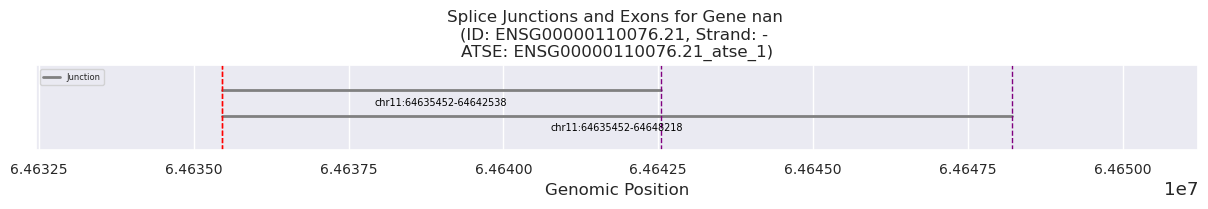

Saved plot to ENSG00000110076.21_atse_1.pdf
Processing ENSG00000110076.21_atse_2...
Found 0 transcripts for ENSG00000110076.21_atse_2


/gpfs/commons/home/kisaev/LeafletFA-utils/leafletfa_utils/atseviz/main.py:257: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all axes decorations.
  plt.tight_layout()


Plot saved to ENSG00000110076.21_atse_2.pdf!


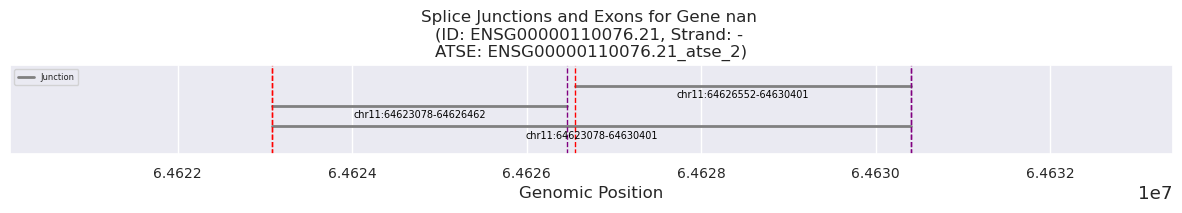

Saved plot to ENSG00000110076.21_atse_2.pdf
Processing ENSG00000110076.21_atse_3...
Found 0 transcripts for ENSG00000110076.21_atse_3
Plot saved to ENSG00000110076.21_atse_3.pdf!


/gpfs/commons/home/kisaev/LeafletFA-utils/leafletfa_utils/atseviz/main.py:257: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all axes decorations.
  plt.tight_layout()


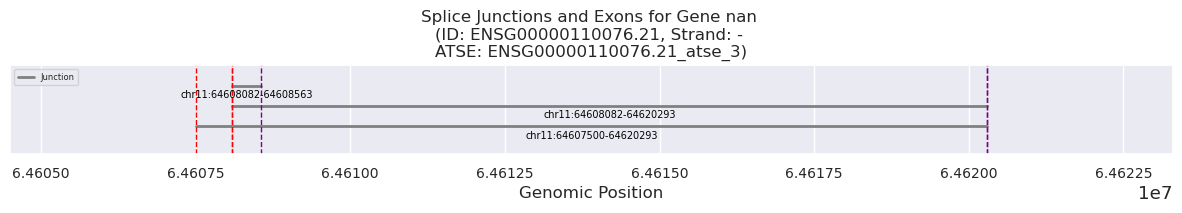

Saved plot to ENSG00000110076.21_atse_3.pdf


In [41]:
# Loop over all unique ATSE event IDs
for atse_event in gene_vals["event_id"].unique():
    print(f"Processing {atse_event}...")

    try:
        # Subset and prepare junctions for this ATSE
        juncs = atses[atses["event_id"] == atse_event].copy()
        if juncs.empty:
            print(f"No junctions found for {atse_event}, skipping.")
            continue

        # Normalize usage_ratio
        total_score_sum = juncs["total_score"].sum()
        if total_score_sum == 0:
            print(f"Total score is zero for {atse_event}, skipping.")
            continue

        juncs.loc[:, "usage_ratio"] = juncs["total_score"] / total_score_sum
        juncs.loc[:, "Cluster"] = juncs["event_id"]

        # Convert junctions to plotting format
        splice_junctions = convert_junction_ids(juncs)

        # Extract associated transcripts
        unique_transcripts = extract_unique_transcripts(juncs)
        if len(unique_transcripts) == 0:
            print(f"No transcripts found for {atse_event}, skipping.")
            continue

        unique_transcripts = [t for t in unique_transcripts if t.startswith('ENST')]

        # Fetch transcript annotations
        transcript_data = fetch_transcripts_and_annotations(db, unique_transcripts)

        # Extract transcript metadata
        conversions = {}
        for t in transcript_data.keys():
            conversions[t] = {
                "transcript_name": transcript_data[t]["transcript_name"],
                "transcript_type": transcript_data[t]["transcript_type"],
                "transcript_id": transcript_data[t]["transcript_id"]
            }

        conversions_df = pd.DataFrame.from_dict(conversions, orient="index")
        print(f"Found {len(conversions_df)} transcripts for {atse_event}")

        # Determine region to plot
        region_start, region_end = determine_region_boundaries(splice_junctions)

        # Output filename per event
        filename = f"{atse_event.replace(':', '_')}.pdf"

        # Plot the event
        plot_exons_and_junctions(
            db,
            atse_event,
            transcript_data,
            splice_junctions,
            region_start-2000,
            region_end+2000,
            base_width=15,
            trans_height=0.8,
            show_usage=False,
            show_junc_lines=True,
            filename=filename
        )

        print(f"Saved plot to {filename}")

    except Exception as e:
        print(f"Error processing {atse_event}: {e}")

# Select junction from dropdown and grey out the transcripts that don't contain it... 
# Something to make it easier to see junction to transcript relationships... 
# Decide if want to show the novel isoforms or not... 
# Github repo for Dashboard to move to knowles lab github repo